In [1]:
import platform
platform.platform()

'macOS-15.6.1-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt

In [6]:
import pandas as pd
pd.__version__

'2.3.3'

In [7]:
from rdkit import Chem, rdBase
rdBase.rdkitVersion

'2023.09.1'

In [8]:
from rdkit.Chem import AllChem, Draw

In [9]:
from SSMetrics import ecfp

In [10]:
df1 = pd.read_csv("../../1_dataset/1_28descriptors/1_dataset/1_original/dataset.csv",
                  usecols=["InChI"])
df1.shape

(4665, 1)

In [11]:
df2 = ecfp(df1["InChI"])
df2.shape

(4665, 2048)

In [12]:
df2.columns

RangeIndex(start=0, stop=2048, step=1)

In [13]:
df2

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4660,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4661,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4662,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4663,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
len(df2)

4665

In [15]:
sum_sr = df2.sum(numeric_only=True)
sum_sr.sort_values(ascending=False, inplace=True)
sum_sr

1602    4665
1873    4665
807     4665
1380    4665
1750    4458
        ... 
717        0
1051       0
1721       0
706        0
0          0
Length: 2048, dtype: int64

In [16]:
sum_sr.to_csv("ecfp_frequencies.csv")

In [17]:
sum_sum_sr = sum_sr.value_counts(sort=False)
sum_sum_sr

4665      4
4458      1
3119      1
3009      1
3006      1
       ... 
4        96
3        86
2       105
1        74
0        64
Name: count, Length: 288, dtype: int64

In [18]:
sum_sum_sr.to_csv("ecfp_frequencies_value_counts.csv")

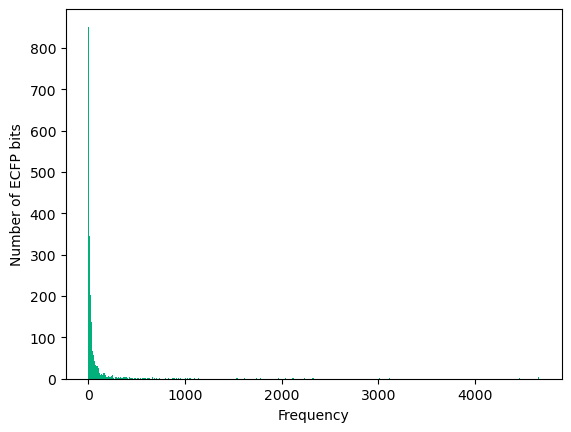

In [19]:
fig = plt.figure()
ax = fig.add_subplot()

y = sum_sr.values

ax.hist(y, bins=466, color=(3/255, 175/255, 122/255))

ax.set_xlabel("Frequency")
ax.set_ylabel("Number of ECFP bits")

plt.savefig("ecfp_frequencies_hist.png", dpi=300)
plt.show()

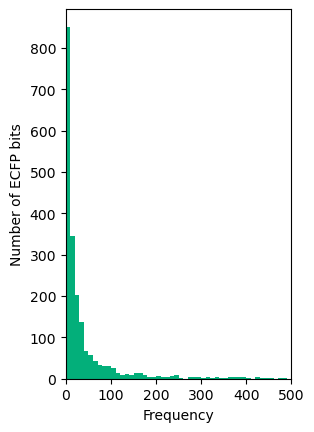

In [20]:
fig = plt.figure()
ax = fig.add_subplot(1, 2, 1)

y = sum_sr.values

ax.hist(y, bins=466, color=(3/255, 175/255, 122/255))

ax.set_xlabel("Frequency")
ax.set_ylabel("Number of ECFP bits")

ax.set_xlim(0, 500)

plt.savefig("ecfp_frequencies_hist_500.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
bit_list = list(sum_sr[sum_sr.values == 1].index)
bit_list.sort()
bit_list

[47,
 73,
 86,
 146,
 153,
 173,
 211,
 244,
 264,
 266,
 326,
 331,
 360,
 414,
 423,
 532,
 533,
 545,
 546,
 560,
 604,
 611,
 615,
 639,
 702,
 709,
 734,
 761,
 792,
 887,
 962,
 1021,
 1040,
 1062,
 1069,
 1072,
 1170,
 1186,
 1194,
 1202,
 1214,
 1303,
 1315,
 1334,
 1345,
 1373,
 1383,
 1394,
 1424,
 1426,
 1474,
 1478,
 1505,
 1562,
 1575,
 1600,
 1646,
 1682,
 1732,
 1743,
 1776,
 1788,
 1826,
 1829,
 1857,
 1863,
 1864,
 1967,
 1974,
 2005,
 2014,
 2021,
 2032,
 2037]

In [22]:
len(bit_list)

74

In [23]:
draw_list = []
for bit in bit_list:
    for i in range(len(df2)):

        if df2.at[i, bit] == 1:
            mol = Chem.MolFromInchi(df1["InChI"][i])
            Draw.MolToFile(mol, f"ecfp_freq1/{bit}.svg", imageType="svg")

            info = {}
            AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048, bitInfo=info)
            svg = Draw.DrawMorganBit(mol, bit, info, legend=str(bit), useSVG=True)

            with open(f"ecfp_freq1/{bit}_bit.svg", mode="w") as f:
                f.write(svg.data)
            break